In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize

Question 0.1

In [ ]:
#This cell estimates theta3, which is the empirical distribution of mileage increments given no replacement next period. 
df = pd.read_csv('rust_data_2020.csv', index_col=0)
df = df.sort_values(['bus_id', 'period_id']).reset_index(drop=True)

df['x_next'] = df.groupby('bus_id')['x_it'].shift(-1)
df['y_next'] = df.groupby('bus_id')['y_it'].shift(-1)
df['delta_x']= df['x_next'] - df['x_it']

mask = (df['y_next'] == 0) & df['x_next'].notna()
deltas = df.loc[mask, 'delta_x'].astype(int)

support = [0, 1, 2, 3, 4]
counts = deltas.value_counts().reindex(support, fill_value=0)
theta3 = (counts / counts.sum()).values 

print(f"Total transitions used: {len(deltas):,}")
print()
print("Empirical distribution of Δx given y_{t+1} = 0:")
print(f"{'Δx':>4} | {'count':>6} | {'P(Δx)':>8}")
print("-" * 26)
for d, c, p in zip(support, counts.values, theta3):
    print(f"{d:>4} | {c:>6} | {p:>8.4f}")
print("-" * 26)
print(f"{'sum':>4} | {counts.sum():>6} | {theta3.sum():>8.4f}")
print()
print(f"theta3 = {np.round(theta3, 4)}")

Total transitions used: 7,174

Empirical distribution of Δx given y_{t+1} = 0:
  Δx |  count |    P(Δx)
--------------------------
   0 |    650 |   0.0906
   1 |   3125 |   0.4356
   2 |   3322 |   0.4631
   3 |     77 |   0.0107
   4 |      0 |   0.0000
--------------------------
 sum |   7174 |   1.0000

theta3 = [0.0906 0.4356 0.4631 0.0107 0.    ]


Question 0.2

In [ ]:
# Builds a 201x201 transition matrix for action y=0 from theta3.
N = 201                        
Pi = np.zeros((N, N))

for x in range(N):
    for k, p in enumerate(theta3):
        x_next = x+k
        if x_next >= N-1:    
            Pi[x, N-1] += p
        else:
            Pi[x, x_next] += p

assert np.allclose(Pi.sum(axis=1), 1.0)

Question 1.1

In [ ]:
# Bellman. Uses a hybrid solver. 
N = 201
post_reset = np.zeros(N); post_reset[:5] = theta3
x_grid = np.arange(N)

def bellman_T(W, EV1, theta1, RC, beta):
    u0 = -0.001*theta1*x_grid
    u1 = np.full(N, -RC)
    v0 = u0 +beta*W
    v1 = u1+beta*EV1
    m = np.maximum(v0,v1)
    e0, e1 = np.exp(v0-m),np.exp(v1-m)
    L = m+np.log(e0+e1)
    P0 = e0/(e0+e1)
    return Pi @ L, post_reset @L,P0

def solve_EV(theta1, RC, beta=0.9999, tol=1e-12, vfi_max=200, newton_max=100, switch_tol=1e-3):
    W,EV1 = np.zeros(N), 0.0

    for _ in range(newton_max):
        W_new, EV1_new, P0 = bellman_T(W, EV1, theta1, RC, beta)
        F = np.concatenate([W_new - W, [EV1_new - EV1]])    # <-- this line
        if np.max(np.abs(F)) < tol:
            break
        Tp = np.zeros((N + 1, N + 1))
        Tp[:N, :N] = Pi * (beta * P0)[None, :]
        Tp[:N,  N] = Pi @ (beta * (1 - P0))
        Tp[N , :N] = post_reset * (beta * P0)
        Tp[N ,  N] = post_reset @ (beta * (1 - P0))
        delta = np.linalg.solve(Tp - np.eye(N + 1), F)
        W, EV1 = W - delta[:N], EV1 - delta[N]
    return W, EV1, P0


Question 1.2

In [ ]:
# Conditional choice probabilities
def compute_ccp(theta1, RC, beta=0.9999):
    W, EV1, P0 = solve_EV(theta1, RC, beta)
    return 1.0 - P0, P0, W, EV1

Question 1.3

In [ ]:
#Log-likelihood and analytical gradient. 
def loglik_and_grad(params, y, x, beta=0.9999):
    RC, theta1 = params
    W, EV1, P0 = solve_EV(theta1, RC, beta)
    P1 = 1.0 - P0
    
    logP0 = np.log(np.clip(P0, 1e-300, 1.0))
    logP1 = np.log(np.clip(P1, 1e-300, 1.0))
    ell = (y * logP1[x] + (1 - y) * logP0[x]).sum()

    M = np.zeros((N+1, N+1))
    M[:N, :N] = Pi * (beta*P0)[None, :]
    M[:N,  N] = Pi @ (beta*(1 - P0))
    M[N , :N] = post_reset*(beta * P0)
    M[N ,  N] = post_reset @ (beta * (1 - P0))
    A = np.eye(N+1) - M

    dT = np.zeros((N+1, 2))
    dT[:N, 0] = Pi @ (-P1); dT[N, 0] = post_reset @ (-P1)       
    dT[:N, 1] = Pi @ (-0.001 * x_grid * P0); dT[N, 1] = post_reset @ (-0.001 * x_grid * P0)
    dz = np.linalg.solve(A, dT)
    dW_dRC, dEV1_dRC = dz[:N, 0], dz[N, 0]
    dW_dth1, dEV1_dth1 = dz[:N, 1], dz[N, 1]

    dv0_dRC = beta * dW_dRC; dv1_dRC = -1.0 + beta * dEV1_dRC
    dv0_dth1 = -0.001 * x_grid + beta * dW_dth1; dv1_dth1 = beta * dEV1_dth1

    dlogP1_dRC = dv1_dRC - (P0 * dv0_dRC  + P1 * dv1_dRC)
    dlogP0_dRC = dv0_dRC- (P0 * dv0_dRC  + P1 * dv1_dRC)
    dlogP1_dth1 = dv1_dth1 - (P0 * dv0_dth1 + P1 * dv1_dth1)
    dlogP0_dth1 = dv0_dth1 - (P0 * dv0_dth1 + P1 * dv1_dth1)

    grad = np.array([
        (y * dlogP1_dRC[x] + (1 - y) * dlogP0_dRC[x]).sum(),
        (y * dlogP1_dth1[x] + (1 - y) * dlogP0_dth1[x]).sum(),
    ])
    return ell, grad

Question 1.4

N obs = 7450,  N replacements = 276,  rate = 0.0370
  start=(10.0, 2.5) -> RC=13.5326, θ11=25.5959, LL=-861.9923, ok=False
  start=(5.0, 1.0) -> RC=13.5326, θ11=25.5959, LL=-861.9923, ok=True
  start=(15.0, 5.0) -> RC=13.5326, θ11=25.5959, LL=-861.9923, ok=True
  start=(8.0, 3.0) -> RC=13.5326, θ11=25.5959, LL=-861.9923, ok=True

========== MLE results ==========
RC      = 13.5326   (SE = 0.9103)
theta11 = 25.5959   (SE = 2.1523)
LL      = -861.9923


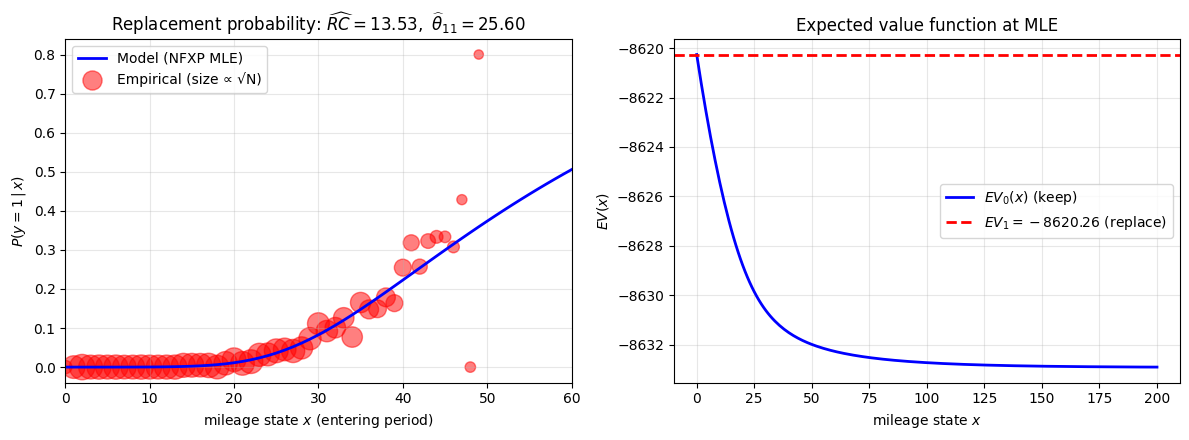

In [ ]:
#MLE 
df = pd.read_csv('rust_data_2020.csv', index_col=0)
df = df.sort_values(['bus_id', 'period_id']).reset_index(drop=True)
df['x_prev'] = df.groupby('bus_id')['x_it'].shift(1)
mask = df['x_prev'].notna()
y = df.loc[mask,'y_it'].values.astype(int)
x = df.loc[mask, 'x_prev'].values.astype(int)

print(f"N obs = {len(y)},  N replacements = {y.sum()},  rate = {y.mean():.4f}")
beta = 0.9999

def neg_ll_and_grad(params, y, x, beta):
    ell, grad = loglik_and_grad(params, y, x, beta)
    return -ell, -grad

starts = [(10.0, 2.5), (5.0, 1.0), (15.0, 5.0), (8.0, 3.0)]
results = []
for sp in starts:
    res = minimize(neg_ll_and_grad, x0=np.array(sp), args=(y, x, beta), method='BFGS', jac=True, options={'gtol': 1e-6})
    results.append(res)
    print(f"  start={sp} -> RC={res.x[0]:.4f}, θ11={res.x[1]:.4f}, " f"LL={-res.fun:.4f}, ok={res.success}")

res = max(results, key=lambda r: -r.fun)
RC_hat, th1_hat = res.x

H = np.zeros((2, 2))
eps = 1e-5
for j in range(2):
    pp = res.x.copy(); pp[j] += eps
    pm = res.x.copy(); pm[j] -= eps
    _, gp = loglik_and_grad(pp, y, x, beta)
    _, gm = loglik_and_grad(pm, y, x, beta)
    H[:, j] = (gp - gm) / (2 * eps)
H = 0.5 * (H + H.T)
V  = -np.linalg.inv(H)
se = np.sqrt(np.diag(V))

print("\n========== MLE results ==========")
print(f"RC      = {RC_hat:.4f}   (SE = {se[0]:.4f})")
print(f"theta11 = {th1_hat:.4f}   (SE = {se[1]:.4f})")
print(f"LL      = {-res.fun:.4f}")

W_mle, EV1_mle, P0_mle = solve_EV(th1_hat, RC_hat, beta)
P1_mle = 1.0 - P0_mle

emp = pd.DataFrame({'x': x, 'y': y}).groupby('x')['y'].agg(['mean', 'count']).reset_index()
emp = emp[emp['count'] >= 5]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ax = axes[0]
ax.plot(x_grid[:80], P1_mle[:80], 'b-', lw=2, label='Model (NFXP MLE)')
ax.scatter(emp['x'], emp['mean'], s=20*np.sqrt(emp['count']),
           color='red', alpha=0.5, label='Empirical (size ∝ √N)')
ax.set_xlabel('mileage state $x$ (entering period)')
ax.set_ylabel(r'$P(y=1\,|\,x)$')
ax.set_title(rf'Replacement probability: $\widehat{{RC}}={RC_hat:.2f},'
             rf'\ \widehat{{\theta}}_{{11}}={th1_hat:.2f}$')
ax.set_xlim(0, 60)
ax.legend(); ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(x_grid, W_mle, 'b-', lw=2, label=r'$EV_0(x)$ (keep)')
ax.axhline(EV1_mle, color='r', ls='--', lw=2,
           label=rf'$EV_1 = {EV1_mle:.2f}$ (replace)')
ax.set_xlabel('mileage state $x$')
ax.set_ylabel(r'$EV(x)$')
ax.set_title('Expected value function at MLE')
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('nfxp_mle.png', dpi=130, bbox_inches='tight')
plt.show()